# 35: the archive showcase

Two public archives, the NGL GPS station network and the NOAA Global
Hourly weather network, reduced to images once on a workstation and
carried across the wire to a Raspberry Pi 5 that never sees a raw sample.
This notebook does not reduce or fit again: it reads the tracked tables
`ngl-reduce`, `ngl-fits`, `ngl-exact`, `isd-reduce`, `isd-fits`, `isd-exact`
and the leg-5 wire tables produced earlier by
`python -m dtfit_experimental.study.showcase.cli` and asks what they show,
then reruns a handful of stations end to end where the archives are on
disk.

Claims:

1. A fit read back from the stored image agrees with the fit from the raw
   samples to the machine's own rounding, on both real archives, not only
   on the synthetic record of notebook 22. False if a station whose
   conditioning does not explain the miss scores worse than 1e-8.
2. The image is not a free win everywhere: NOAA's coarse hourly grid
   collapses into a stored image two orders of magnitude smaller than the
   raw archive, while NGL's already-compact GPS series barely breaks even,
   and a fifth of its stations' stored images outgrow their own raw file.
   False if the notebook's own numbers do not show that asymmetry.
3. The resident memory of a reduction pass stays flat as the file count
   grows tenfold. False if the peak scales up with the corpus the way the
   raw bytes do.
4. The Raspberry Pi refits every station-year from the images alone, at a
   rate that keeps a whole year's worth of stations inside a few minutes.
   False if a Pi-side fit disagrees with its own PC-side row or the run
   does not finish.
5. The GPU leg is a loss once the host transfer is counted, on the real
   archive widths, matching the controlled sweep of notebook 22. False if
   any width favors cupy.
6. The image travels the wire bit for bit from the Pi to the PC: a
   station's blocks reassembled locally digest the same as the ones the
   network carried. Separately, a live replay of raw samples from the PC
   to the Pi and block images back raises the same drift flags as a
   from-disk run. False if any group mismatches or a flag count
   disagrees.

What follows works from the tracked CSVs; the last section reruns a small
sample of stations end to end and skips with one line when neither archive
is on disk.

In [1]:
import os
import time
import tempfile
from pathlib import Path

import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt

from dtfit_experimental.study import paths as study_paths
from dtfit_experimental.study import ngl, notebook
from dtfit_experimental.study.showcase import (
    compare, isd_fits, isd_reduce, ngl_fits, ngl_reduce,
)
from dtfit_experimental.study.showcase import paths as sc_paths
from dtfit_experimental.study.showcase.store import read_table

STARTED = time.time()
QUICK = os.environ.get("DTFIT_QUICK") == "1"
plt.rcParams["figure.dpi"] = 110

RESULTS = sc_paths.results_dir()
NGL_TENV3 = study_paths.ngl_dir() / "tenv3"
ISD_YEAR = study_paths.isd_dir(2024)
HAVE_NGL = NGL_TENV3.is_dir() and any(NGL_TENV3.glob("*.tenv3"))
HAVE_ISD = ISD_YEAR.is_dir() and any(ISD_YEAR.glob("*.csv*"))
N_RERUN = 2 if QUICK else 5
N_RERUN_ISD = 2 if QUICK else 3
print(f"QUICK={QUICK} tables under experiments/results/{RESULTS.name}")
print("NGL archive found" if HAVE_NGL else f"NGL archive absent at {NGL_TENV3}")
print("ISD archive found" if HAVE_ISD else f"ISD archive absent at {ISD_YEAR}")

QUICK=False tables under experiments/results/35_archive_showcase
NGL archive found
ISD archive found


## 1. What ran where

Every subcommand of the showcase CLI wrote a `<name>_timing.csv` row next
to its table: the host, the command, the row count and the wall time. One
table over all of them says which machine produced which number.

In [2]:
timing_files = sorted(RESULTS.glob("*_timing*.csv"))
timing_rows = []
for f in timing_files:
    for row in read_table(f):
        timing_rows.append({"file": f.name, **row})
timing = pd.DataFrame(timing_rows)
timing["rows"] = timing["rows"].astype(int)
timing["seconds"] = timing["seconds"].astype(float)
timing = timing.sort_values(["host", "command", "file"]).reset_index(drop=True)
notebook.save_table("35_archive_showcase", "headline", timing)
timing

,file,host,command,rows,seconds
0,filters_isd_timing.csv,Finality,filters-isd,2470,45.024
1,filters_ngl_timing.csv,Finality,filters-ngl,15558,166.467
2,gemm_timing.csv,Finality,gemm,18,1861.455
3,isd_exact_timing.csv,Finality,isd-exact,12677,121.742
4,isd_exact_timing_days.csv,Finality,isd-exact,465,10.101
5,isd_exact_timing_subset.csv,Finality,isd-exact,200,3.629
6,isd_year_fits_timing.csv,Finality,isd-fits,12677,15.729
7,isd_normals_timing.csv,Finality,isd-normals,6034,113.291
8,isd_reduce_timing.csv,Finality,isd-reduce,13345,49.320
9,isd_reduce_timing_normals.csv,Finality,isd-reduce,465,8.641


In [3]:
# fails if a run recorded on only one host slipped in (the claim is about
# two machines) or if a command's timing row carries a non-positive time
assert timing.host.nunique() >= 2
assert (timing.seconds > 0).all()
by_host = timing.groupby("host").seconds.sum().sort_values(ascending=False)
print(f"{len(timing)} timing rows over {timing.host.nunique()} hosts, "
      f"{timing.seconds.sum() / 60:.1f} minutes combined")
print(by_host)

36 timing rows over 2 hosts, 280.3 minutes combined
host
felled-pi    10534.434
Finality      6285.029
Name: seconds, dtype: float64


`Finality` is the workstation that reduced both archives and fitted from
the images; `felled-pi` is the Raspberry Pi 5 that received the images
over the network and refitted them without ever holding a raw sample. The
Pi's own `isd-fits` row is section 4's headline number.

## 2. Compression and what sets it

`ngl-reduce` and `isd-reduce` wrote every row this section reads, one per
station or station-year. Every reduced row carries its raw file size
beside the stored `.npz` and the three in-memory arrays (`S`, `G`, the
explicit grid). Two ratios come out of that, and they are not the same
thing: the *stored* ratio is what a `.npz` on disk buys against the raw
file, the *in-memory* ratio is what the bare arrays a running process
holds buy against it, before whatever compression
`numpy.savez_compressed` finds.

In [4]:
def compression_row(dataset, csv_name):
    df = pd.read_csv(RESULTS / csv_name, low_memory=False)
    good = df[df.error.isna()].copy()
    failed = df[df.error.notna()]
    raw = good.raw_bytes.astype(float).sum()
    stored = good.npz_bytes.astype(float).sum()
    mem = (good.coef_bytes.astype(float) + good.gram_bytes.astype(float)
           + good.grid_bytes.astype(float)).sum()
    both = good.dropna(subset=["npz_bytes", "raw_bytes"])
    larger = float((both.npz_bytes.astype(float)
                    > both.raw_bytes.astype(float)).mean())
    return {
        "dataset": dataset, "n_stations": len(df), "n_reduced": len(good),
        "n_failed": len(failed),
        "raw_gb": raw / 1e9, "stored_gb": stored / 1e9,
        "mem_gb": mem / 1e9,
        "stored_ratio": raw / stored,
        "mem_ratio": raw / mem,
        "share_stored_larger": larger,
        "failed_raw_gb": failed.raw_bytes.astype(float).sum() / 1e9,
    }


compression = pd.DataFrame([
    compression_row("ngl", "ngl_reduce.csv"),
    compression_row("isd", "isd_reduce.csv"),
]).set_index("dataset")
compression.round(4)

,n_stations,n_reduced,n_failed,raw_gb,stored_gb,mem_gb,stored_ratio,mem_ratio,share_stored_larger,failed_raw_gb
dataset,,,,,,,,,,
ngl,23769,23175,594,17.0046,14.4147,18.4016,1.1797,0.9241,0.1933,0.0015
isd,13345,12677,668,51.5868,0.2871,0.9960,179.6776,51.7919,0.0000,0.2917


In [5]:
row = compression.loc["isd"]
# fails if the stored ISD image did not collapse the raw archive by at
# least two orders of magnitude
assert row.stored_ratio > 100
row = compression.loc["ngl"]
# fails if NGL's share of stations whose stored image outgrows its raw
# file moved out of the band this archive measured it in
assert 0.15 <= row.share_stored_larger <= 0.25
for name in ("isd", "ngl"):
    r = compression.loc[name]
    print(f"{name.upper()}: {r.n_reduced:.0f} reduced files, "
          f"{r.raw_gb:.2f} GB raw against {r.stored_gb:.3f} GB stored "
          f"({r.stored_ratio:.2f}x) and {r.mem_gb:.3f} GB in memory "
          f"({r.mem_ratio:.2f}x)")
    print(f"{name.upper()}: {r.n_failed:.0f} files failed to reduce, "
          f"{r.failed_raw_gb:.4f} GB raw, in none of the three sums")
print(f"{compression.loc['ngl'].share_stored_larger:.1%} of the reduced NGL "
      f"stations' stored image is bigger than their raw file.")

ISD: 12677 reduced files, 51.59 GB raw against 0.287 GB stored (179.68x) and 0.996 GB in memory (51.79x)
ISD: 668 files failed to reduce, 0.2917 GB raw, in none of the three sums
NGL: 23175 reduced files, 17.00 GB raw against 14.415 GB stored (1.18x) and 18.402 GB in memory (0.92x)
NGL: 594 files failed to reduce, 0.0015 GB raw, in none of the three sums
19.3% of the reduced NGL stations' stored image is bigger than their raw file.


              n_stations  median_span  median_order  median_ratio
span (years)                                                     
(0, 1]              1336         0.63          21.0          1.63
(1, 3]              2652         2.00          32.0          2.37
(3, 10]             7025         6.25          66.0          2.13
(10, 20]            8351        14.72         133.0          1.21
(20, 35]            3811        23.81         206.0          0.99


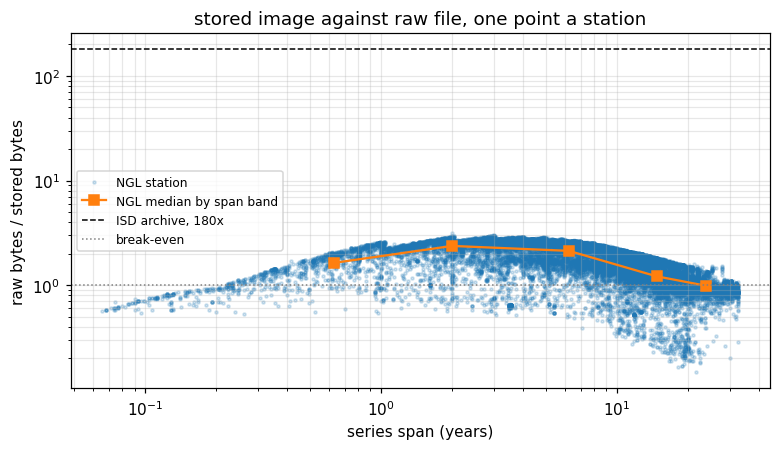

In [6]:
ngl_reduce_rows = pd.read_csv(RESULTS / "ngl_reduce.csv", low_memory=False)
ngl_ok = ngl_reduce_rows[ngl_reduce_rows.error.isna()]
ngl_ratio = ngl_ok.raw_bytes.astype(float) / ngl_ok.npz_bytes.astype(float)
bands = pd.cut(ngl_ok.span, [0, 1, 3, 10, 20, 35])
by_band = pd.DataFrame({
    "n_stations": ngl_ratio.groupby(bands, observed=True).size(),
    "median_span": ngl_ok.span.groupby(bands, observed=True).median(),
    "median_order": ngl_ok.order.groupby(bands, observed=True).median(),
    "median_ratio": ngl_ratio.groupby(bands, observed=True).median(),
})
by_band.index.name = "span (years)"
print(by_band.round(2))

isd_ratio = float(compression.loc["isd"].stored_ratio)
fig, ax = plt.subplots(figsize=(7.2, 4.2))
ax.scatter(ngl_ok.span, ngl_ratio, s=4, c="tab:blue", alpha=0.2,
           label="NGL station")
ax.plot(by_band.median_span, by_band.median_ratio, "s-", c="tab:orange",
        label="NGL median by span band")
ax.axhline(isd_ratio, color="black", ls="--", lw=1,
           label=f"ISD archive, {isd_ratio:.0f}x")
ax.axhline(1.0, color="0.5", ls=":", lw=1, label="break-even")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("series span (years)")
ax.set_ylabel("raw bytes / stored bytes")
ax.set_title("stored image against raw file, one point a station")
ax.legend(fontsize=8, loc="center left")
ax.grid(True, which="both", alpha=0.3)
fig.tight_layout()
plt.show()

ISD's hourly grid is what the order policy exploits: a station-year of up
to 8784 rows is represented at a fixed order 24, so the reduction grows
with the sample count and NOAA's aggregate lands near two orders of
magnitude. NGL's raw `.tenv3` rows are already one line a day, close to
what a Legendre coefficient buys back, so the order the span-and-density
rule assigns (order 100 and above for a multi-decade station) leaves the
Gram matrix, which grows as the order squared, as large as or larger than
the row it replaces for a good share of the network. The order policy
sets the ratio, not the method: a station this dense gains from fewer,
better-chosen coefficients, not from more of them.

The figure carries one point a reduced station. The ratio peaks in the
middle of the range, a median 2.37x between one and three years, and
falls to 0.99x above twenty years, where the rule has assigned a median
order of 206 and the Gram matrix costs about what the rows it replaces
do; the shortest stations, under a year, sit at 1.63x. ISD's whole
archive is at 180x, above the entire NGL cloud, on a fixed order 24 and
an hourly year.

## 3. The exactness gate

`ngl-exact` and `isd-exact` fit the stored image and the raw least squares
on the very same rows and score the worst relative parameter difference;
`isd-exact --with-days` gates a sample of the one-day channel-form images
the same way. A row whose sampling cannot support the fitted order is
`UNDERSAMPLED`, one whose conditioning explains a miss within tolerance is
`ILL-CONDITIONED`, and only a miss beyond both is `FAIL`. The claim is
about the rows the gate passed: their worst score, not the worst
score of every row including the ones the gate already excused.

In [7]:
def gate_summary(name, csv_name):
    df = pd.read_csv(RESULTS / csv_name, low_memory=False)
    ok = df[df.gate == "ok"]
    counts = df.gate.value_counts()
    return {
        "table": name, "n_rows": len(df), "n_ok": len(ok),
        "worst_ok_score": ok.score.max() if len(ok) else float("nan"),
        "n_ill_conditioned": int(counts.get("ILL-CONDITIONED", 0)),
        "n_undersampled": int(counts.get("UNDERSAMPLED", 0)),
        "n_fail": int(counts.get("FAIL", 0)),
    }


gate = pd.DataFrame([
    gate_summary("ngl_exact", "ngl_exact.csv"),
    gate_summary("isd_exact", "isd_exact.csv"),
    gate_summary("isd_exact_days", "isd_exact_days.csv"),
]).set_index("table")
gate

,n_rows,n_ok,worst_ok_score,n_ill_conditioned,n_undersampled,n_fail
table,,,,,,
ngl_exact,69525,66708,9.967323e-09,1275,1542,0
isd_exact,12677,11711,9.628281e-09,835,131,0
isd_exact_days,465,465,3.528010e-10,0,0,0


In [8]:
# fails if any of the three tables' passing rows carries a score above the
# gate's own tolerance, i.e. the gate is passing rows it should not
assert (gate.worst_ok_score <= 1e-8).all(), gate.worst_ok_score
# fails if a row's conditioning does not excuse its miss: claim 1's own
# falsifier, which the tolerance check above cannot see
assert (gate.n_fail == 0).all(), gate.n_fail
print(f"worst score among passing rows: {gate.worst_ok_score.max():.2e}")
print(f"NGL: {gate.loc['ngl_exact'].n_ok} ok, "
      f"{gate.loc['ngl_exact'].n_undersampled} undersampled, "
      f"{gate.loc['ngl_exact'].n_ill_conditioned} ill-conditioned "
      f"of {gate.loc['ngl_exact'].n_rows}")
print(f"ISD: {gate.loc['isd_exact'].n_ok} ok, "
      f"{gate.loc['isd_exact'].n_ill_conditioned} ill-conditioned, "
      f"{gate.loc['isd_exact'].n_undersampled} undersampled "
      f"of {gate.loc['isd_exact'].n_rows} station-years")

worst score among passing rows: 9.97e-09
NGL: 66708.0 ok, 1542.0 undersampled, 1275.0 ill-conditioned of 69525.0
ISD: 11711.0 ok, 835.0 ill-conditioned, 131.0 undersampled of 12677.0 station-years


Every row the gate passed agrees with the raw solve to about 1e-8 or
better, on both networks and on the day images that back the channel-form
projection of section 5. NGL splits close to evenly between the two
excuses, 1542 undersampled against 1275 ill-conditioned (a short segment
below the density floor, or a gap that leaves the Gram matrix nearly
singular); ISD's excused rows are mostly conditioning, 835 against 131
undersampled (a partial year leaves the annual terms poorly identified
more often than a station-year falls short on rows). Neither failure mode
is the method missing a fit: both are the image reporting, correctly,
that its order cannot be trusted on that station.

## 4. Flat memory and throughput, PC against Raspberry Pi

`throughput` was run at 200 files and again at 2000 (`--suffix _n4000`;
the row's `n_files` is set before reduction starts, so the 60 files that
failed to reduce out of the 2000 do not change the count), on the PC and,
at 200 files, on the Pi. `peak_rss_mib` is this process's resident set,
what the claim below is about; `peak_mib` is `tracemalloc`'s traced
allocation high-water mark, a different and much smaller number.

In [9]:
mem = pd.concat([
    pd.read_csv(RESULTS / "throughput.csv").assign(run="pc_200"),
    pd.read_csv(RESULTS / "throughput_n4000.csv").assign(run="pc_2000"),
    pd.read_csv(RESULTS / "throughput_pi.csv").assign(run="pi_200"),
])
reduce_rows = mem[mem.route.str.startswith("cpu")]
reduce_rows[["run", "host", "route", "workers", "n_files",
             "samples_per_second", "peak_mib", "peak_rss_mib", "note"]]

,run,host,route,workers,n_files,samples_per_second,peak_mib,peak_rss_mib,note
1,pc_200,Finality,cpu-1,1,200,85566.2,48.86,674.53,0 failed
2,pc_200,Finality,cpu-12,12,200,267553.6,0.23,747.29,0 failed
1,pc_2000,Finality,cpu-1,1,2000,76040.7,49.78,671.79,60 failed
2,pc_2000,Finality,cpu-12,12,2000,599621.8,1.87,762.81,60 failed
1,pi_200,felled-pi,cpu-1,1,200,23483.0,48.77,230.00,0 failed
2,pi_200,felled-pi,cpu-4,4,200,44638.9,0.22,422.65,0 failed


In [10]:
pc = reduce_rows[(reduce_rows.host == "Finality") & (reduce_rows.workers == 1)]
rss_200 = float(pc[pc.run == "pc_200"].peak_rss_mib.iloc[0])
rss_2000 = float(pc[pc.run == "pc_2000"].peak_rss_mib.iloc[0])
growth = abs(rss_2000 - rss_200) / rss_200
# fails if the resident peak grew with the corpus the way the raw bytes
# read did
assert growth < 0.05, growth
print(f"PC cpu-1 resident memory {rss_200:.1f} MiB at 200 files, "
      f"{rss_2000:.1f} MiB at 2000 files ({growth:.1%} change) while the "
      f"raw bytes read grew {pc[pc.run == 'pc_2000'].raw_bytes.iloc[0] / pc[pc.run == 'pc_200'].raw_bytes.iloc[0]:.1f}x")
pi_row = reduce_rows[(reduce_rows.host == "felled-pi") & (reduce_rows.workers == 1)]
pc_row = pc[pc.run == "pc_200"]
print(f"single-worker reduce rate: PC {float(pc_row.samples_per_second.iloc[0]):.0f} "
      f"samples/s, Pi {float(pi_row.samples_per_second.iloc[0]):.0f} samples/s")

PC cpu-1 resident memory 674.5 MiB at 200 files, 671.8 MiB at 2000 files (0.4% change) while the raw bytes read grew 5.8x
single-worker reduce rate: PC 85566 samples/s, Pi 23483 samples/s


In [11]:
isd_fits_timing = pd.concat([
    pd.DataFrame(read_table(RESULTS / 'isd_year_fits_timing.csv')).assign(who='pc'),
    pd.DataFrame(read_table(RESULTS / 'isd_year_fits_timing_pi.csv')).assign(who='pi'),
])
isd_fits_timing['seconds'] = isd_fits_timing.seconds.astype(float)
isd_fits_timing['rows'] = isd_fits_timing.rows.astype(int)
isd_fits_timing

,host,command,rows,seconds,who
0,Finality,isd-fits,12677,15.729,pc
0,felled-pi,isd-fits,12677,294.606,pi


In [12]:
pi_refit = isd_fits_timing[isd_fits_timing.who == 'pi'].iloc[0]
# fails if the Pi did not in fact refit every station-year the PC did
assert int(pi_refit['rows']) == 12677
print(f"the Pi refitted {int(pi_refit['rows'])} station-years from their "
      f"stored images alone in {float(pi_refit['seconds']):.1f} s "
      f"({float(pi_refit['seconds']) / int(pi_refit['rows']) * 1000:.2f} ms each)")

the Pi refitted 12677 station-years from their stored images alone in 294.6 s (23.24 ms each)


In [13]:
isd_year_fits_pc = pd.DataFrame(read_table(RESULTS / "isd_year_fits.csv"))
isd_year_fits_pi = pd.DataFrame(read_table(RESULTS / "isd_year_fits_pi.csv"))
isd_pi_check = isd_year_fits_pc.merge(
    isd_year_fits_pi, on=["station", "year", "field"], suffixes=("_pc", "_pi"),
)
isd_exact_gate = pd.read_csv(RESULTS / "isd_exact.csv", low_memory=False)
isd_exact_gate["year"] = isd_exact_gate.year.astype(str)
fit_fields = ["a1", "a2", "b1", "b2", "c", "v", "annual_amp"]
rel = pd.concat([
    (isd_pi_check[f"{f}_pc"].astype(float)
     - isd_pi_check[f"{f}_pi"].astype(float)).abs()
    / isd_pi_check[f"{f}_pc"].astype(float).abs().clip(lower=1e-6)
    for f in fit_fields
], axis=1)
isd_pi_check["worst_rel"] = rel.max(axis=1)
isd_pi_check = isd_pi_check.merge(
    isd_exact_gate[["station", "year", "field", "gate"]],
    on=["station", "year", "field"],
)
excused = {"ILL-CONDITIONED", "UNDERSAMPLED"}
disagree = isd_pi_check[isd_pi_check.worst_rel > 1e-6]
# fails if the Pi's own fit disagrees with the PC's on a station-year the
# exactness gate did not already excuse
assert disagree.gate.isin(excused).all(), disagree[~disagree.gate.isin(excused)]
print(f"{len(isd_pi_check) - len(disagree)} of {len(isd_pi_check)} "
      f"station-years' Pi and PC fits agree to better than 1e-6; "
      f"{len(disagree)} disagree, every one on a row the gate already "
      f"excused ({disagree.gate.value_counts().to_dict()}), worst among "
      f"gate-ok rows {isd_pi_check[isd_pi_check.gate == 'ok'].worst_rel.max():.1e}")

12444 of 12677 station-years' Pi and PC fits agree to better than 1e-6; 233 disagree, every one on a row the gate already excused ({'ILL-CONDITIONED': 194, 'UNDERSAMPLED': 39}), worst among gate-ok rows 7.3e-08


The resident peak barely moves between 200 and 2000 files on the PC: the
reduction holds one station's arrays at a time, so the corpus size does
not enter its footprint. The Pi reduces at roughly a quarter of the PC's
single-worker rate (its `cpu-1` row above), but the fit from a stored
image is cheap enough that refitting all 12677 station-years still lands
in under five minutes on the weaker machine, without opening a single raw
CSV. Its fit agrees with the PC's own on every station-year the exactness
gate passed; where the two disagree by more than 1e-6, the gate had
already excused the row.

## 5. The GPU row as a loss

`gemm` swept the channel-form projection over real ISD batch widths (500,
5000 and every station of 2024, at 1, 7 and 30 concatenated days), numpy
against cupy, with the host transfer counted on the cupy side. Notebook
22 makes the same claim under a controlled synthetic sweep; this section
checks it holds at archive scale.

In [14]:
gemm = pd.read_csv(RESULTS / "gemm.csv")
gemm = gemm[gemm.seconds.notna()]
pivot = gemm.pivot_table(
    index=["channels"], columns="backend", values="elements_per_second"
)
pivot["cupy_over_numpy"] = pivot["cupy"] / pivot["numpy"]
pivot

backend,cupy,numpy,cupy_over_numpy
channels,,,
95,9949597.9,38407765.2,0.259052
661,61326736.6,210977110.7,0.290680
846,41436817.9,251620372.2,0.164680
2808,86687290.6,459111033.1,0.188816
3116,82127243.4,461009262.3,0.178147
5865,111857481.3,577232955.5,0.193782
22288,149859514.4,668516322.9,0.224167
25058,148725001.7,202033327.8,0.736141
94375,146814818.5,238727629.7,0.614989


In [15]:
# fails if cupy (host transfer counted) beat numpy at any measured width
assert (pivot["cupy_over_numpy"] < 1.0).all()
print(f"numpy {gemm[gemm.backend == 'numpy'].elements_per_second.min():.2e} to "
      f"{gemm[gemm.backend == 'numpy'].elements_per_second.max():.2e} elements/s "
      f"against cupy {gemm[gemm.backend == 'cupy'].elements_per_second.min():.2e} "
      f"to {gemm[gemm.backend == 'cupy'].elements_per_second.max():.2e}; "
      f"cupy never wins. See notebook 22 for the controlled sweep and the "
      f"warm-kernel number that isolates the transfer as the cost.")

numpy 3.84e+07 to 6.69e+08 elements/s against cupy 9.95e+06 to 1.50e+08; cupy never wins. See notebook 22 for the controlled sweep and the warm-kernel number that isolates the transfer as the cost.


## 6. Across the wire

`stream-serve` sent block images from the Pi to the PC, and
`stream-replay` separately replayed one station's raw samples live from
the PC while `stream-track` on the Pi tracked them and sent block images
home; `leg5-tables` folds both legs' JSON summaries into the CSVs below.
`leg5_groups.csv` reassembles every station's blocks locally and compares
the digest against what the wire carried; the replay leg swept four
requested rates (1000, 10000, 100000 samples/s and unbounded), each
checked against a fresh run of the same detection filter on the replayed
stations' own files.

In [16]:
leg5_stream = pd.read_csv(RESULTS / "leg5_stream.csv")
leg5_groups = pd.read_csv(RESULTS / "leg5_groups.csv")
leg5_replay = pd.read_csv(RESULTS / "leg5_replay.csv")

_local_flags = int(leg5_replay.n_flags.iloc[0])
_rate_tags = ["1000", "10000", "100000", "unbounded"]
leg5_rate_rows = []
for tag in _rate_tags:
    send = pd.read_csv(RESULTS / f"leg5_replay_rate_{tag}.csv").iloc[0]
    recv = pd.read_csv(RESULTS / f"leg5_track_rate_{tag}.csv").iloc[0]
    leg5_rate_rows.append({
        "rate_tag": tag,
        "rate_achieved": float(send.samples_per_second),
        "dropped_sender": int(send.n_dropped),
        "dropped_receiver": int(recv.n_dropped),
        "n_flags": int(recv.n_flags),
        "flags_match": (int(send.n_dropped) == 0 and int(recv.n_dropped) == 0
                        and int(recv.n_flags) == _local_flags),
    })
leg5_rates = pd.DataFrame(leg5_rate_rows)
leg5_stream

,direction,block_years,n_images,bytes_header,bytes_payload,seconds,images_per_second,latency_ms_median,latency_ms_p90,clock_delta_s,groups,n_flags,mismatched
0,pi->pc,1.00,2000,13470863,2912000,85.5507,23.378,41.9985,42.6392,0.0282,141,3,0
1,local,0.25,3210,6549799,4673760,142.2472,22.566,NaN,NaN,0.0005,60,52,0
2,local,4.00,228,5354167,331968,10.0910,22.594,NaN,NaN,0.0009,60,0,0


In [17]:
# fails if any station's locally reassembled blocks digest differently
# from what the wire carried
assert (leg5_groups.mismatched == 0).all()
assert (leg5_stream.mismatched == 0).all()
# fails if a rate that dropped no frames on either end still disagreed on
# the flag count, claim 6's falsifier isolated from link congestion
assert bool(leg5_rates[leg5_rates.dropped_receiver == 0].flags_match.all())
pi_to_pc = leg5_stream[leg5_stream.direction == "pi->pc"].iloc[0]
replay = leg5_replay.iloc[0]
print(f"{int(pi_to_pc.n_images)} images Pi to PC at "
      f"{pi_to_pc.images_per_second:.1f} images/s, "
      f"{int(pi_to_pc.groups)} groups bit-exact")
print(f"the replay ran at {replay.us_per_update:.0f} us an update, "
      f"{int(replay.n_flags)} flags equal to the from-disk run")
print(leg5_rates)
n_match = int(leg5_rates.flags_match.sum())
print(f"{n_match} of {len(leg5_rates)} measured rates matched the "
      f"from-disk flag count ({_local_flags}); the link saturates near "
      f"{leg5_rates.rate_achieved.max():.0f} samples/s and flags are "
      f"missed once frames drop above that")

2000 images Pi to PC at 23.4 images/s, 141 groups bit-exact
the replay ran at 400 us an update, 22 flags equal to the from-disk run
    rate_tag  rate_achieved  dropped_sender  dropped_receiver  n_flags  \
0       1000          999.6               0                 0       22   
1      10000         2677.0               3                 2       16   
2     100000         2703.5               5                 4       11   
3  unbounded         2670.2               0                 0       22   

   flags_match  
0         True  
1        False  
2        False  
3         True  
2 of 4 measured rates matched the from-disk flag count (22); the link saturates near 2704 samples/s and flags are missed once frames drop above that


## 7. The rerun, end to end

Everything above reads what an earlier run wrote. This section reruns a
handful of stations from scratch, on whatever archive is on disk right
now: the exactness gate over a few stations of each network, then a fresh
reduce and fit into a temporary directory, checked against the tracked
rows the commands above already wrote -- `ngl-exact`, `ngl-reduce` and
`ngl-fits` for NGL, `isd-exact`, `isd-reduce` and `isd-fits` for ISD. It
skips with one line, leaving the tables above untouched, when an archive
is absent.

In [18]:
rerun_exactness_rows = []
rerun_fit_rows = []

if HAVE_NGL:
    tracked_exact = pd.read_csv(RESULTS / "ngl_exact.csv", low_memory=False)
    ok_stations = sorted(tracked_exact[tracked_exact.gate == "ok"].sta.unique())
    ngl_stations = ok_stations[:N_RERUN]
    images_dir = study_paths.showcase_root() / "images" / "ngl"
    pairs = [(NGL_TENV3 / f"{s}.tenv3", images_dir / f"{s}.npz")
             for s in ngl_stations]
    started = time.perf_counter()
    exact_rows = ngl_fits.run_exactness(pairs)
    exact_seconds = time.perf_counter() - started
    for row in exact_rows:
        row["archive"] = "ngl"
        rerun_exactness_rows.append(row)

    with tempfile.TemporaryDirectory() as tmp:
        started = time.perf_counter()
        steps = {
            sta: [s.year for s in group]
            for sta, group in ngl.read_steps(
                study_paths.ngl_dir() / "steps.txt"
            ).items()
        }
        reduce_rows = ngl_reduce.reduce_many(
            [p for p, _ in pairs], tmp, steps,
        )
        reduce_seconds = time.perf_counter() - started
        midas_file = study_paths.ngl_dir() / "midas.IGS20.txt"
        midas = ngl.read_midas(midas_file) if midas_file.exists() else {}
        fresh_npz = [Path(tmp) / f"{s}.npz" for s in ngl_stations]
        started = time.perf_counter()
        fresh_fits = ngl_fits.run_fits(fresh_npz, midas)
        fit_seconds = time.perf_counter() - started

    tracked_fits = pd.DataFrame(read_table(RESULTS / "ngl_fits.csv.gz"))
    tracked_whole = tracked_fits[(tracked_fits.kind == "whole")
                                  & (tracked_fits.sta.isin(ngl_stations))]
    fresh = pd.DataFrame([r for r in fresh_fits if r.get("kind") == "whole"])
    for _, fr in fresh.iterrows():
        match = tracked_whole[(tracked_whole.sta == fr.sta)
                               & (tracked_whole.component == fr.component)]
        if len(match) == 0:
            continue
        for name in ngl_reduce.NGL_NAMES:
            tracked_value = float(match[name].iloc[0])
            rerun_fit_rows.append({
                "archive": "ngl", "station": fr.sta,
                "component": fr.component, "parameter": name,
                "rerun": float(fr[name]), "tracked": tracked_value,
                "rel_diff": abs(float(fr[name]) - tracked_value)
                / max(abs(tracked_value), 1e-6),
            })
    print(f"NGL rerun: {len(ngl_stations)} stations, exactness "
          f"{exact_seconds:.2f} s, reduce {reduce_seconds:.2f} s, "
          f"fit {fit_seconds:.2f} s")
else:
    print("NGL archive absent, skipping the NGL rerun")

NGL rerun: 5 stations, exactness 1.26 s, reduce 0.54 s, fit 0.85 s


In [19]:
if HAVE_ISD:
    tracked_exact_isd = pd.read_csv(RESULTS / "isd_exact.csv", low_memory=False)
    ok_years = sorted(
        tracked_exact_isd[tracked_exact_isd.gate == "ok"].station.astype(str).unique()
    )
    isd_stations = ok_years[:N_RERUN_ISD]
    images_dir = study_paths.showcase_root() / "images" / "isd" / "2024"
    pairs_isd = [(ISD_YEAR / f"{s}.csv.gz", images_dir / f"{s}.npz")
                 for s in isd_stations]
    pairs_isd = [(c if c.exists() else ISD_YEAR / f"{s}.csv", n)
                 for (c, n), s in zip(pairs_isd, isd_stations)]
    started = time.perf_counter()
    exact_isd_rows = isd_fits.run_exactness_isd(pairs_isd)
    exact_isd_seconds = time.perf_counter() - started
    for row in exact_isd_rows:
        row["archive"] = "isd"
        rerun_exactness_rows.append(row)

    with tempfile.TemporaryDirectory() as tmp:
        started = time.perf_counter()
        isd_reduce.reduce_many_years([c for c, _ in pairs_isd], tmp)
        reduce_isd_seconds = time.perf_counter() - started
        fresh_npz_isd = [Path(tmp) / f"{s}.npz" for s in isd_stations]
        started = time.perf_counter()
        fresh_year_fits = isd_fits.run_year_fits(fresh_npz_isd)
        fit_isd_seconds = time.perf_counter() - started

    tracked_year_fits = pd.DataFrame(read_table(RESULTS / "isd_year_fits.csv"))
    fresh_isd = pd.DataFrame(fresh_year_fits)
    for _, fr in fresh_isd.iterrows():
        match = tracked_year_fits[
            (tracked_year_fits.station.astype(str) == str(fr.station))
            & (tracked_year_fits.field == fr.field)
        ]
        if len(match) == 0:
            continue
        for name in isd_reduce.ANNUAL_NAMES:
            tracked_value = float(match[name].iloc[0])
            rerun_fit_rows.append({
                "archive": "isd", "station": fr.station,
                "component": fr.field, "parameter": name,
                "rerun": float(fr[name]), "tracked": tracked_value,
                "rel_diff": abs(float(fr[name]) - tracked_value)
                / max(abs(tracked_value), 1e-6),
            })
    print(f"ISD rerun: {len(isd_stations)} station-years, exactness "
          f"{exact_isd_seconds:.2f} s, reduce {reduce_isd_seconds:.2f} s, "
          f"fit {fit_isd_seconds:.2f} s")
else:
    print("ISD archive absent, skipping the ISD rerun")

ISD rerun: 3 station-years, exactness 0.15 s, reduce 0.05 s, fit 0.03 s


In [20]:
if rerun_exactness_rows:
    rerun_exactness = pd.DataFrame(rerun_exactness_rows)
    # fails if a freshly gated station did not clear its own gate
    assert (rerun_exactness.gate == "ok").all(), rerun_exactness.gate.value_counts()
    if QUICK:
        print("QUICK: skipping the CSV export")
    else:
        notebook.save_table("35_archive_showcase", "rerun_exactness", rerun_exactness)
    print(rerun_exactness[["archive", "gate", "score"]])
else:
    print("neither archive present; nothing to gate")

if rerun_fit_rows:
    rerun_reduce_fit = pd.DataFrame(rerun_fit_rows)
    worst_by_parameter = rerun_reduce_fit.groupby(
        ["archive", "parameter"]).rel_diff.max()
    # fails if a refit from a fresh reduction drifts from the tracked
    # archive run in any parameter, past the exactness gate's tolerance
    assert (rerun_reduce_fit.rel_diff <= compare.EXACTNESS_TOL).all(), \
        worst_by_parameter
    if QUICK:
        print("QUICK: skipping the CSV export")
    else:
        notebook.save_table("35_archive_showcase", "rerun_reduce_fit", rerun_reduce_fit)
    print(f"{len(rerun_reduce_fit)} parameter comparisons against the "
          f"tracked rows, worst relative difference each:")
    print(worst_by_parameter)
else:
    print("neither archive present; nothing to refit")

   archive gate         score
0      ngl   ok  2.568276e-11
1      ngl   ok  2.400721e-11
2      ngl   ok  3.795919e-10
3      ngl   ok  5.040965e-10
4      ngl   ok  2.810467e-10
5      ngl   ok  9.538658e-10
6      ngl   ok  2.326258e-10
7      ngl   ok  7.710451e-10
8      ngl   ok  4.937593e-10
9      ngl   ok  9.793067e-14
10     ngl   ok  8.339615e-14
11     ngl   ok  1.940958e-13
12     ngl   ok  7.548426e-13
13     ngl   ok  2.233193e-13
14     ngl   ok  9.643998e-13
15     isd   ok  3.532805e-13
16     isd   ok  3.352884e-12
17     isd   ok  2.760127e-14
108 parameter comparisons against the tracked rows, worst relative difference each:
archive  parameter
isd      a1           0.0
         a2           0.0
         b1           0.0
         b2           0.0
         c            0.0
         v            0.0
ngl      a1           0.0
         a2           0.0
         b1           0.0
         b2           0.0
         c            0.0
         v            0.0
Name: rel_diff,

## Findings and limits

Every row either gate passed agrees with the raw least squares to about
1e-8, on both real archives and on the sampled day images, and every one
of the five NGL stations and three ISD station-years rerun from scratch
in this notebook cleared its own gate again and matched all six fitted
parameters of its tracked row to the same tolerance. The order policy,
not the method, sets how much a network compresses: NOAA's hourly grid
gives two orders of magnitude, NGL's near-daily one barely breaks even
and a fifth of its stations' stored images outgrow their raw file. Memory
stays flat as the
corpus grows tenfold. The Pi refits every ISD station-year from images
alone inside five minutes without touching a raw file. The GPU leg loses
at every real archive width once the transfer is counted, the same
reading notebook 22 gives on a synthetic sweep. The wire carries the
image bit for bit from the Pi to the PC, and a live replay in the other
direction raises the same drift flags as reading the file as long as
neither end drops a frame; the link saturates near 2.7 kHz and starts
missing flags once frames drop above that.

Limits: the order policy behind NGL's near-parity ratio is a fixed rule,
not tuned per station; a policy that priced the Gram matrix's growth
against the row it replaces would likely improve it, and that is not
measured here. The gated station-years are one calendar year of ISD and
whatever NGL currently holds; a longer or shorter span moves the
undersampled and ill-conditioned counts. The GPU reading rests on one
GPU, one CUDA build and one host link. The Pi's numbers are one Raspberry
Pi 5 on one occasion; no repeat spread is reported for its wall times.

In [21]:
limits = pd.DataFrame([
    {"topic": "NGL compression",
     "limit": "fixed span-and-density order policy, not tuned per station"},
    {"topic": "gated station-years",
     "limit": "one calendar year of ISD (2024) and the NGL archive as reduced now"},
    {"topic": "GPU leg",
     "limit": "one GPU, one CUDA build, one host link"},
    {"topic": "Pi numbers",
     "limit": "one Raspberry Pi 5 on one occasion, no repeat spread"},
])
notebook.save_table("35_archive_showcase", "limits", limits)
limits

,topic,limit
0,NGL compression,"fixed span-and-density order policy, not tuned..."
1,gated station-years,one calendar year of ISD (2024) and the NGL ar...
2,GPU leg,"one GPU, one CUDA build, one host link"
3,Pi numbers,"one Raspberry Pi 5 on one occasion, no repeat ..."


In [22]:
print(notebook.provenance(STARTED))

2026-09-21 commit d3e267d dtfit 0.4.0 dtfit-experimental 0.1.0 5.2s
